# Extract individual trajectories from one recording

In [1]:
import sys
import numpy as np
sys.path.append("../")
sys.path.append("../src")
sys.path.append("../src/models")
sys.path.append("../src/data")
sys.path.append("../src/utils")
sys.path.append("../src/data/components/")
sys.path.append("../src/models/components/")
sys.path.append("../src/utils/IEBCS")
sys.path.append("../src/utils/IEBCS/representations")
import eventIO
import event_representations
from player import VideoPlayer
import cv2
from event_buffer import EventBuffer

In [2]:
buf = eventIO.load_hdf5("/home/lkolmar/Documents/metavision/recordings/dataset_full_ball-gun/hdf5/" + "spin_0_rec1_converted.hdf5")

Event rates (in ms): [2 0 0 ... 0 0 1]


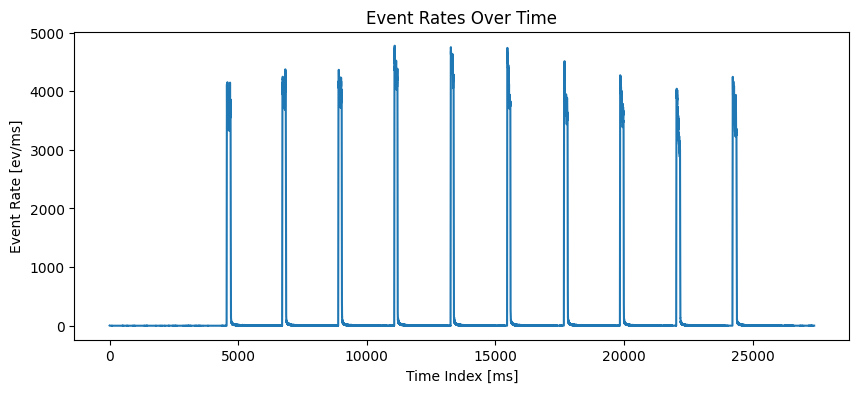

In [3]:
event_rates = buf.ms_to_idx[1:] - buf.ms_to_idx[:-1]
print("Event rates (in ms):", event_rates)
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 4))
plt.plot(event_rates)
plt.xlabel("Time Index [ms]")
plt.ylabel("Event Rate [ev/ms]")
plt.title("Event Rates Over Time")
plt.show()

## Extract timeframes with high event-rates

In [4]:
threshold = 1000  # Set a threshold for event rates [ev/ms]
high_rate_idxs = np.where(event_rates > threshold)[0]

# Group consecutive indices into individual spikes
spikes = []
if len(high_rate_idxs) > 0:
    current_spike = [high_rate_idxs[0]]
    for idx in high_rate_idxs[1:]:
        if idx == current_spike[-1] + 1:
            current_spike.append(idx)
        else:
            spikes.append(current_spike)
            current_spike = [idx]
    spikes.append(current_spike)

print(len(spikes))
print(spikes[0][0], spikes[0][-1])

10
4551 4712


## Get events for one spike

In [5]:
idx_spike1 = buf.ms_to_idx[spikes[0][0]], buf.ms_to_idx[spikes[0][-1]]
x_spike_1 = buf.get_x()[idx_spike1[0]:idx_spike1[1]]
y_spike_1 = buf.get_y()[idx_spike1[0]:idx_spike1[1]]
p_spike_1 = buf.get_p()[idx_spike1[0]:idx_spike1[1]]
ts_spike_1 = buf.get_ts()[idx_spike1[0]:idx_spike1[1]]

buf_spike1 = eventIO.EventBuffer(0)
buf_spike1.x = x_spike_1
buf_spike1.y = y_spike_1
buf_spike1.p = p_spike_1
buf_spike1.ts = ts_spike_1
buf_spike1.i = x_spike_1.shape[0]

## get images

In [6]:
print(buf_spike1.get_ts().min(), buf_spike1.get_ts().max(), buf_spike1.get_ts().max() - buf_spike1.get_ts().min())
start_ts = buf_spike1.get_ts().min()
end_ts = buf_spike1.get_ts().max()
print("Start time:", start_ts, "End time:", end_ts)
print(type(start_ts), type(end_ts))

4551000 4711998 160998
Start time: 4551000 End time: 4711998
<class 'numpy.uint64'> <class 'numpy.uint64'>


In [7]:
timeframe_us = 1000
start_ts = buf_spike1.get_ts().min()
end_ts = buf_spike1.get_ts().max()
end_ts += timeframe_us
end_ts = int(end_ts)
frames = []
for i in range(start_ts, end_ts, timeframe_us):
    idxs = np.where((buf_spike1.get_ts() >= i) & (buf_spike1.get_ts() < i + timeframe_us))[0]
    # print(idxs.shape)
    if len(idxs) == 0:
        frames.append(np.zeros((720, 1280), dtype=np.uint8))  # Append an empty frame if no events
        print(f"Empty frame at {i}")
    else:
        frame = event_representations.events_to_image(buf_spike1.get_x()[idxs], buf_spike1.get_y()[idxs], buf_spike1.get_ts()[idxs], buf_spike1.get_p()[idxs])
        frames.append(frame)

print(f"Generated {len(frames)} frames")

/home/lkolmar/dev/Master_Thesis/notebooks/../src/utils/event_representations.py:31: RuntimeWarning: invalid value encountered in divide
  ps_normalized = ((ps - min_p) / (max_p - min_p) * 255).astype(np.uint8)
/home/lkolmar/dev/Master_Thesis/notebooks/../src/utils/event_representations.py:31: RuntimeWarning: invalid value encountered in cast
  ps_normalized = ((ps - min_p) / (max_p - min_p) * 255).astype(np.uint8)


Empty frame at 4712000
Generated 162 frames


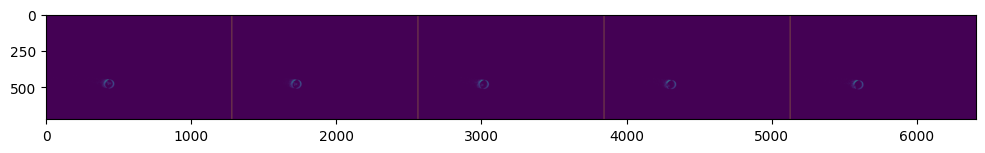

In [8]:
voxel = np.stack(frames[50:55], axis=0)
plt.imshow(event_representations.get_voxel_grid_as_image(voxel))
plt.gcf().set_size_inches(12, 8)
plt.show()

## Use player

In [9]:
# Map background to dark blue and event values to light blue
frames_img = []
for frame in frames:
    norm_frame = ((frame / 12) * 255).clip(0, 255).astype(np.uint8)
    img = np.zeros((norm_frame.shape[0], norm_frame.shape[1], 3), dtype=np.uint8)
    # Set background to dark blue
    img[:, :, 2] = 40  # B
    img[:, :, 1] = 0   # G
    img[:, :, 0] = 0   # R
    # Set event pixels to light blue
    mask = norm_frame > 0
    # print(norm_frame.shape, frame.shape, mask.shape, img.shape)
    img[mask, 2] = 220  # B
    img[mask, 1] = 180  # G
    img[mask, 0] = 100  # R
    frames_img.append(img)

In [10]:
def ev_frame_to_img(f):
    norm_frame = ((f / 12) * 255).clip(0, 255).astype(np.uint8)
    img = np.zeros((norm_frame.shape[0], norm_frame.shape[1], 3), dtype=np.uint8)
    # Set background to dark blue
    img[:, :, 2] = 40  # B
    img[:, :, 1] = 0   # G
    img[:, :, 0] = 0   # R
    # Set event pixels to light blue
    mask = norm_frame > 0
    # print(norm_frame.shape, frame.shape, mask.shape, img.shape)
    img[mask, 2] = 220  # B
    img[mask, 1] = 180  # G
    img[mask, 0] = 100  # R
    return img

In [11]:
app = VideoPlayer(frames_img, fps=30)
app.mainloop()

## Find ROI

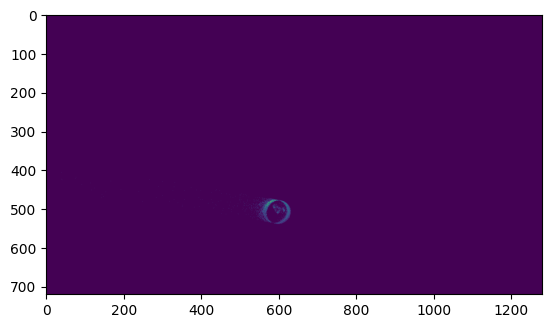

In [12]:
evs_mv = eventIO.buffer_to_array(buf_spike1)
ev_it = eventIO.EventIterator(evs_mv, tw_us=timeframe_us)
number = 70
i = 0

for evs in ev_it:
    frame0 = evs
    i += 1
    if i == number:
        break

plt.imshow(event_representations.events_to_image(frame0["x"], frame0["y"], frame0["t"], frame0["p"]))
plt.show()

## RANSAC aproach

In [13]:
from skimage import io, color, util, filters, feature, morphology, measure

In [14]:
def find_circle(arr, ransac_residual=2.0, canny_sigma=2.0, min_object_area=40):
    """
    Find circle inside event-frame

    """
    hi = np.percentile(arr, 99.8)
    hi = hi if hi > 0 else (arr.max() if arr.max() > 0 else 1.0)
    img_norm = np.clip(arr / hi, 0, 1)

    nz = img_norm[img_norm > 0]
    if nz.size == 0:
        thr = 0.0
    else:
        thr = max(np.percentile(nz, 99.0), filters.threshold_otsu(nz), 0.2)
        thr = float(np.clip(thr, 0.2, 0.95))
    mask = img_norm > thr
    mask = morphology.remove_small_objects(mask, min_size=min_object_area)
    if mask.any():
        lab = measure.label(mask)
        regions = measure.regionprops(lab)
        if regions:
            largest = max(regions, key=lambda r: r.area).label
            mask = (lab == largest)
    mask = morphology.binary_closing(mask, morphology.disk(2))
    mask = morphology.remove_small_holes(mask, area_threshold=256)

    edges = feature.canny(img_norm, sigma=canny_sigma, mask=mask)
    ys, xs = np.nonzero(edges)
    pts = np.column_stack([xs, ys])

    H, W = img_norm.shape
    cy = cx = r = None
    if pts.shape[0] >= 20:
        try:
            model_robust, inliers = measure.ransac(
                pts, measure.CircleModel, min_samples=3,
                residual_threshold=ransac_residual, max_trials=5000
            )
            if model_robust is not None:
                cx_r, cy_r, r_r = model_robust.params
                if (0 <= cx_r < W) and (0 <= cy_r < H) and (5 <= r_r <= max(H, W)):
                    cx, cy, r = float(cx_r), float(cy_r), float(r_r)
        except Exception:
            pass

    # Fallback
    if r is None:
        if mask.any():
            yy, xx = np.nonzero(mask)
            w = img_norm[yy, xx]
            s = w.sum()
            cy = float((yy * w).sum() / s) if s > 0 else float(yy.mean())
            cx = float((xx * w).sum() / s) if s > 0 else float(xx.mean())
            if xs.size >= 5:
                d = np.hypot(xs - cx, ys -cy)
                r = float(np.median(d[d > 0])) if np.any(d > 0) else float(np.sqrt(mask.sum() / np.pi))
            else:
                r = float(np.sqrt(mask.sum() / np.pi))
        else:
            cy, cx, r = np.nan, np.nan, np.nan

    return (cy, cx, r), mask, img_norm, edges

/home/lkolmar/anaconda3/envs/learning/lib/python3.13/site-packages/skimage/measure/fit.py:308: UserWarning: Input does not contain enough significant data points.
  warn("Input does not contain enough significant data points.")


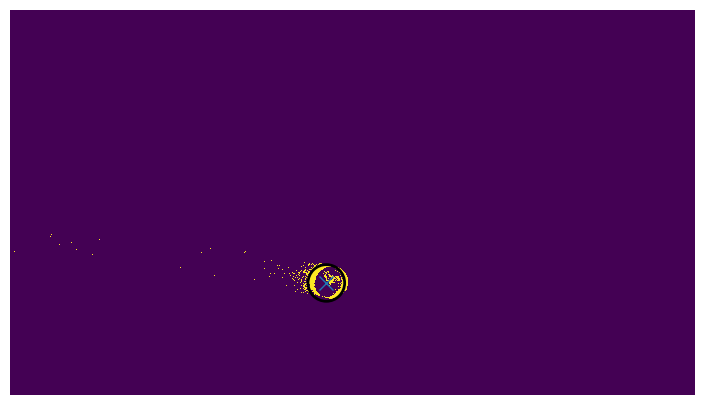

In [15]:
(cy, cx, r), mask, img_norm, edges = find_circle(event_representations.events_to_image(frame0["x"], frame0["y"], frame0["t"], frame0["p"]))
fig, ax = plt.subplots(figsize=(10, 5))
ax.imshow(img_norm, origin="upper", cmap="viridis", interpolation="nearest")
if np.isfinite(cy) and np.isfinite(cx) and np.isfinite(r):
    ax.add_patch(plt.Circle((cx, cy), r, fill=False, linewidth=2))
    ax.plot([cx], [cy], marker="x", markersize=10, linewidth=2)
ax.set_axis_off()

In [16]:
def track_ball(evs):
    input_arr = event_representations.events_to_image(evs["x"], evs["y"], evs["t"], evs["p"])
    input_arr = np.transpose(input_arr, (1, 0))
    (cy, cx, r), mask, img_norm, edges = find_circle(input_arr)
    return cx, cy, img_norm

In [17]:
evs_mv = eventIO.buffer_to_array(buf_spike1)
ev_it = eventIO.EventIterator(evs_mv, tw_us=timeframe_us)
debug_imgs = []

for evs in ev_it:
    x, y, img_norm = track_ball(evs)
    # debug_imgs.append(img_norm)
    ev_frame = event_representations.events_to_image(evs["x"], evs["y"], evs["t"], evs["p"])
    img = ev_frame_to_img(ev_frame)

    # print(img.shape)
    # print(img_norm.shape)

    # debug_imgs.append(img_norm)
    # plt.subplot(1, 2, 1)
    # plt.imshow(img)
    # plt.subplot(1, 2, 2)
    # plt.imshow(img_norm)
    # plt.show()
    # break

    if np.isnan(x):
        print("NaN detected")
        debug_imgs.append(img)
        continue

    left = int(max(x - 50, 0))
    right = int(min(x + 50, img.shape[0] - 1))
    top = int(max(y - 50, 0))
    bottom = int(min(y + 50, img.shape[1] - 1))
    # print(left, right, top, bottom)
    img[left, top:bottom, 0] = 255
    img[right, top:bottom, 0] = 255
    img[left:right, top, 0] = 255
    img[left:right, bottom, 0] = 255
    debug_imgs.append(img)

/home/lkolmar/dev/Master_Thesis/notebooks/../src/utils/event_representations.py:31: RuntimeWarning: invalid value encountered in divide
  ps_normalized = ((ps - min_p) / (max_p - min_p) * 255).astype(np.uint8)
/home/lkolmar/dev/Master_Thesis/notebooks/../src/utils/event_representations.py:31: RuntimeWarning: invalid value encountered in cast
  ps_normalized = ((ps - min_p) / (max_p - min_p) * 255).astype(np.uint8)


NaN detected
NaN detected
NaN detected
NaN detected
NaN detected
NaN detected
NaN detected
NaN detected
NaN detected
NaN detected
NaN detected
NaN detected
NaN detected


In [18]:
app = VideoPlayer(debug_imgs, fps=30)
app.mainloop()

# TODO:
Take all centers and smooth them between every frame

# Do preprocessing

## Cut the recordings

In [18]:
filenames = [
    "spin_0_rec1_converted.hdf5",
    "spin_0_rec2_converted.hdf5",
    "spin_1_rec1_converted.hdf5",
    "spin_1_rec2_converted.hdf5",
    "spin_2_rec1_converted.hdf5",
    "spin_2_rec2_converted.hdf5",
    "spin_3_rec1_converted.hdf5",
    "spin_3_rec2_converted.hdf5",
    "spin_4_rec1_converted.hdf5",
    "spin_4_rec2_converted.hdf5",
    "spin_5_rec1_converted.hdf5",
    "spin_5_rec2_converted.hdf5",
    "spin_6_rec1_converted.hdf5",
    "spin_6_rec2_converted.hdf5",
    "spin_7_rec1_converted.hdf5",
    "spin_7_rec2_converted.hdf5",
    "spin_-1_rec1_converted.hdf5",
    "spin_-1_rec2_converted.hdf5",
    "spin_-2_rec1_converted.hdf5",
    "spin_-2_rec2_converted.hdf5",
    "spin_-3_rec1_converted.hdf5",
    "spin_-3_rec2_converted.hdf5",
    "spin_-4_rec1_converted.hdf5",
    "spin_-4_rec2_converted.hdf5",
    "spin_-5_rec1_converted.hdf5",
    "spin_-5_rec2_converted.hdf5",
    "spin_side_1_rec1_converted.hdf5",
    "spin_side_1_rec2_converted.hdf5",
    "spin_side_2_rec1_converted.hdf5",
    "spin_side_2_rec2_converted.hdf5"
]

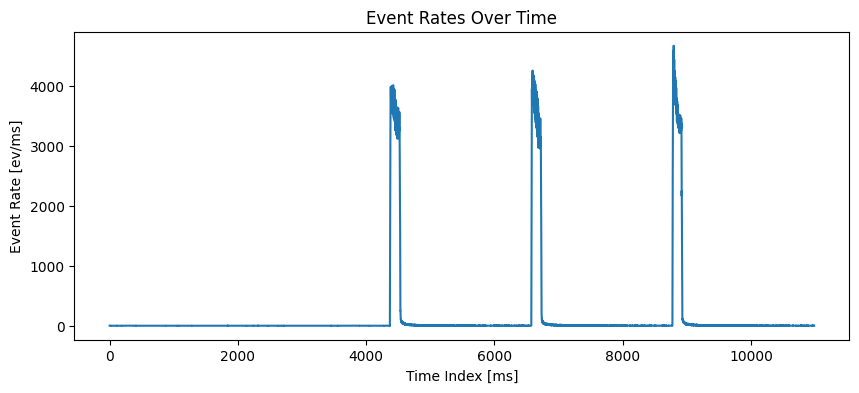

spin_side_2_rec2_converted.hdf5


In [36]:
i = 29 # 0 - 29
filename = filenames[i]

buf = eventIO.load_hdf5("/home/lkolmar/Documents/metavision/recordings/dataset_full_ball-gun/hdf5/" + filename)
event_rates = buf.ms_to_idx[1:] - buf.ms_to_idx[:-1]

plt.figure(figsize=(10, 4))
plt.plot(event_rates)
plt.xlabel("Time Index [ms]")
plt.ylabel("Event Rate [ev/ms]")
plt.title("Event Rates Over Time")
plt.show()
print(filename)

In [34]:
threshold = 1000  # Set a threshold for event rates [ev/ms]
high_rate_idxs = np.where(event_rates > threshold)[0]

# Group consecutive indices into individual spikes
spikes = []
if len(high_rate_idxs) > 0:
    current_spike = [high_rate_idxs[0]]
    for idx in high_rate_idxs[1:]:
        if idx == current_spike[-1] + 1:
            current_spike.append(idx)
        else:
            spikes.append(current_spike)
            current_spike = [idx]
    spikes.append(current_spike)

print(len(spikes))
print(spikes[0][0], spikes[0][-1])

for i in range(len(spikes)):
    idx_spike1 = buf.ms_to_idx[spikes[i][0]], buf.ms_to_idx[spikes[i][-1]]
    x_spike_1 = buf.get_x()[idx_spike1[0]:idx_spike1[1]]
    y_spike_1 = buf.get_y()[idx_spike1[0]:idx_spike1[1]]
    p_spike_1 = buf.get_p()[idx_spike1[0]:idx_spike1[1]]
    ts_spike_1 = buf.get_ts()[idx_spike1[0]:idx_spike1[1]]

    buf_spike1 = eventIO.EventBuffer(0)
    buf_spike1.x = x_spike_1
    buf_spike1.y = y_spike_1
    buf_spike1.p = p_spike_1
    buf_spike1.ts = ts_spike_1
    buf_spike1.i = x_spike_1.shape[0]
    eventIO.save_hdf5(buf_spike1, f"/home/lkolmar/Documents/metavision/recordings/dataset_full_ball-gun/cut/spike_{i}_{filename}", bias=[0])
    print(f"Saved spike {i} with {buf_spike1.i} events.")

3
4371 4530
Saved spike 0 with 537340 events.
Saved spike 1 with 525751 events.
Saved spike 2 with 519866 events.


# Extract ROI

In [ ]:
i = 0
for i in range(1):
    filename_full = filenames[i]
    spike = 0
    for spike in range(10):
        filename = f"/home/lkolmar/Documents/metavision/recordings/dataset_full_ball-gun/cut/spike_{spike}_{filename_full}"

        buf = eventIO.load_hdf5(filename)

        width = 1280
        height = 720

        timeframe_us = 1000
        ev_it = eventIO.EventIterator(eventIO.buffer_to_array(buf), tw_us=timeframe_us)
        out = EventBuffer(0)
        last_pos = (0, 0)

        for evs in ev_it:
            y, x, img_norm = track_ball(evs)

            if np.isnan(x):
                print("NaN detected")
                x = last_pos[0]
                y = last_pos[1]

            left = int(max(x - 50, 0))
            right = int(min(x + 50, width))
            top = int(max(y - 50, 0))
            bottom = int(min(y + 50, height))
            last_pos = (x, y)
            mask = (
                (evs["x"] >= left) & (evs["x"] < right) &
                (evs["y"] >= top) & (evs["y"] < bottom)
            )
            events = evs[mask]
            events["x"] -= left
            events["y"] -= top
            out.add_array(events["t"], events["y"], events["x"], events["p"])
            # print(x, y)

        eventIO.save_hdf5(out, f"/home/lkolmar/Documents/metavision/recordings/dataset_full_ball-gun/roi/roi_{spike}_{filename_full}", bias=[0])
        frames = eventIO.buffer_to_video(out, tw_us=timeframe_us, sensor_size=(100, 100))
        fourcc = cv2.VideoWriter_fourcc('M', 'J', 'P', 'G')
        out_vid = cv2.VideoWriter(f"/home/lkolmar/Documents/metavision/recordings/dataset_full_ball-gun/roi_video/roi_{spike}_{filename_full}.avi", fourcc, 10, (100, 100))
        for frame in frames:
            out_vid.write(frame)
        out_vid.release()


NaN detected
NaN detected
NaN detected
NaN detected
NaN detected
NaN detected
NaN detected
NaN detected
NaN detected
NaN detected
NaN detected
NaN detected
NaN detected
Converted 100 frames, 0 were empty


In [64]:
print(frames[0].shape)

(720, 1280, 3)
